## Random Forest Model with Default Settings

Here we train a Random Forest model using its default settings.
This result will be used later to compare how parameter tuning changes performance.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

In [42]:
# Load the crop dataset
data = pd.read_csv("/content/Crop_recommendation.csv")

# Show the first 5 rows to understand what the data looks like
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Dataset Overview

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [44]:
data['label'].nunique()

22

In [45]:
data['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


## Crop Distribution

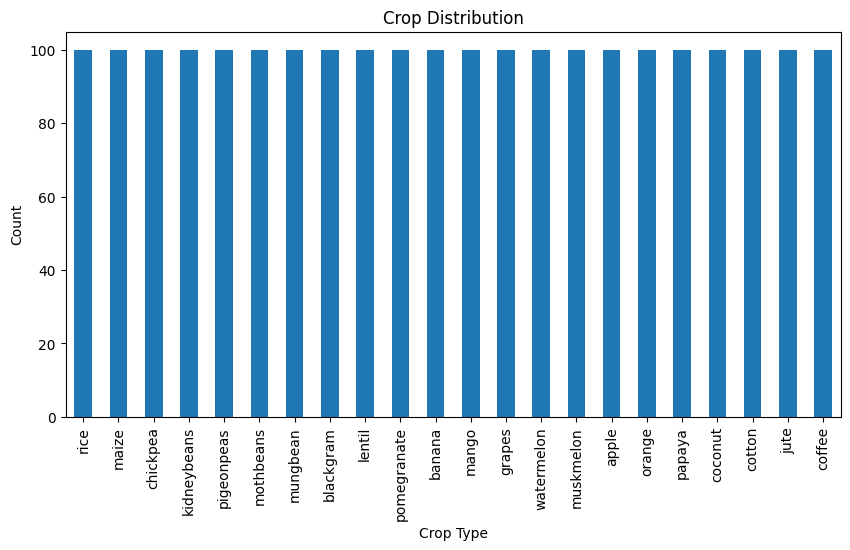

In [46]:
# Create a bar chart to see how crops are distributed in the dataset
data['label'].value_counts().plot(kind='bar', figsize=(10,5))

# Add title and axis labels to make the chart easier to understand
plt.title("Crop Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")

# Show the plot
plt.show()

This chart shows how many samples exist for each crop type. A balanced dataset helps the model
learn each crop category more effectively.

## Feature Correlation Analysis

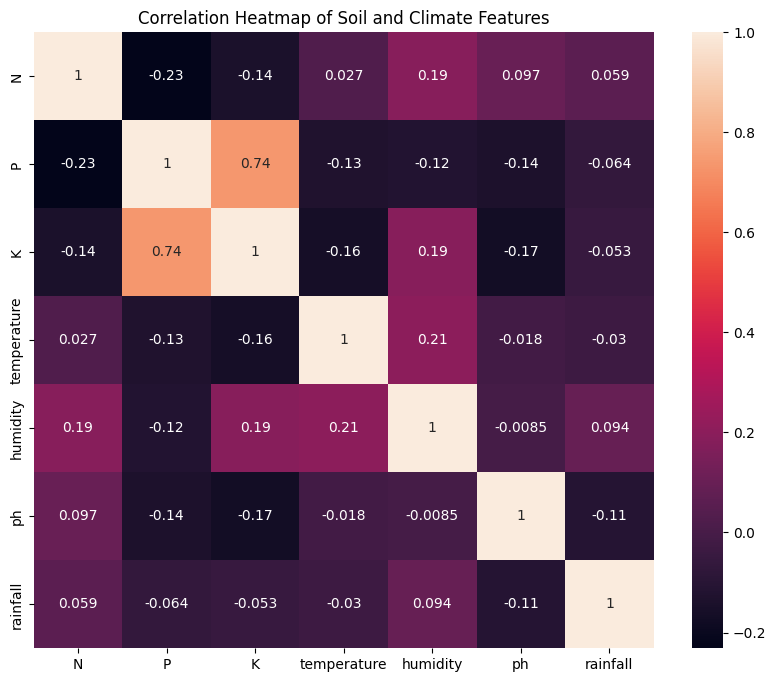

In [47]:
# Create a larger figure so the heatmap is easier to read
plt.figure(figsize=(10,8))

# Show correlation between soil nutrients and climate features
sns.heatmap(data.drop('label', axis=1).corr(), annot=True)
plt.title("Correlation Heatmap of Soil and Climate Features")

# Display the heatmap
plt.show()

The correlation heatmap shows relationships between soil nutrients and climate features.
Most features are not strongly correlated, which means they provide useful independent
information for predicting crop types.

In [48]:
X = data.drop("label", axis=1)
y = data["label"]

In [52]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [16]:
y.head()

,label
0,rice
1,rice
2,rice
3,rice
4,rice


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X_train.shape

(1760, 7)

In [19]:
X_test.shape

(440, 7)

## Random Forest Model Training

In [53]:
# Create a Random Forest model with 100 decision trees
# random_state=42 makes sure results stay the same each time the code runs
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the training data
# The model learns patterns between soil/weather features and crop labels
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [54]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9931818181818182


## Model Evaluation

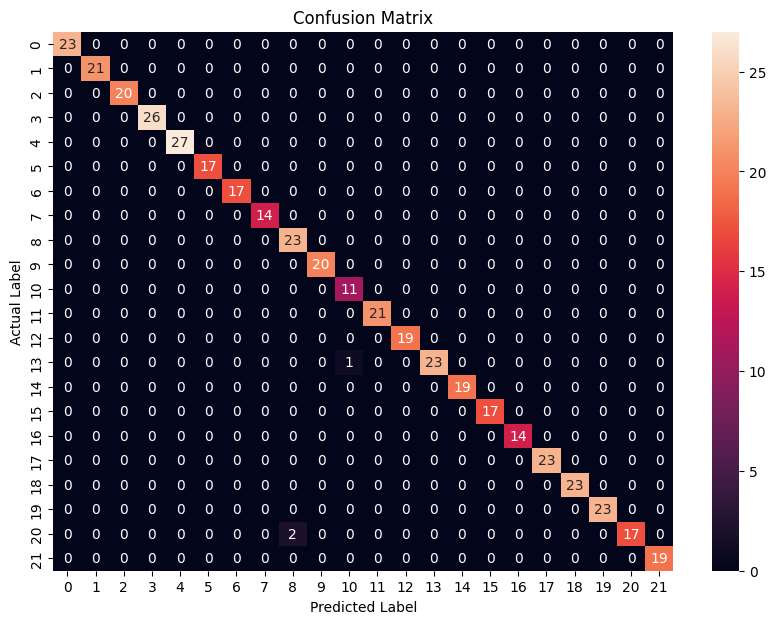

In [55]:
# Create a confusion matrix to compare actual crop labels with predicted labels
cm = confusion_matrix(y_test, predictions)

# Set the figure size so the confusion matrix is easier to read
plt.figure(figsize=(10,7))

# Display the confusion matrix as a heatmap
sns.heatmap(cm, annot=True)

# Add title and axis labels for better understanding
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Show the plot
plt.show()

## Feature Importance Analysis

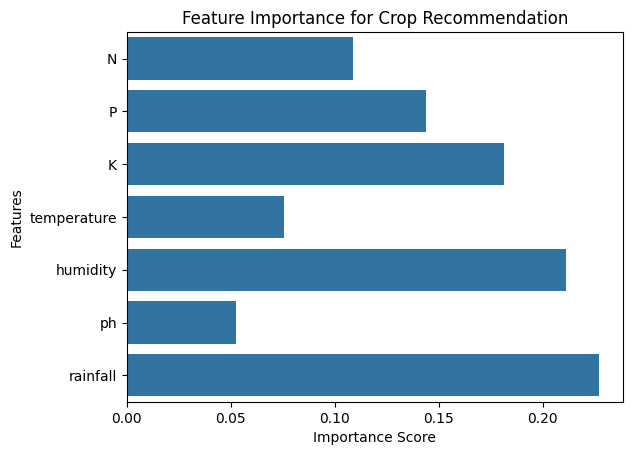

In [56]:
# Get importance scores for each feature from the trained Random Forest model
importance = model.feature_importances_

# Get the names of the input features (soil and weather values)
feature_names = X.columns

# Create a bar chart to show which features are most important for crop prediction
sns.barplot(x=importance, y=feature_names)

# Add title and axis labels to explain the chart clearly
plt.title("Feature Importance for Crop Recommendation")
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Display the plot
plt.show()

Feature importance scores show which soil nutrients and weather conditions influence crop
prediction the most. This helps understand how the model makes decisions.

In [32]:
tree_range = [10, 20, 50, 100, 150, 200]
accuracy_scores = []

## Permutation Feature Importance

In [33]:
for trees in tree_range:
    model_temp = RandomForestClassifier(n_estimators=trees, random_state=42)
    model_temp.fit(X_train, y_train)
    predictions_temp = model_temp.predict(X_test)
    acc = accuracy_score(y_test, predictions_temp)
    accuracy_scores.append(acc)

## Effect of Number of Trees on Model Performance

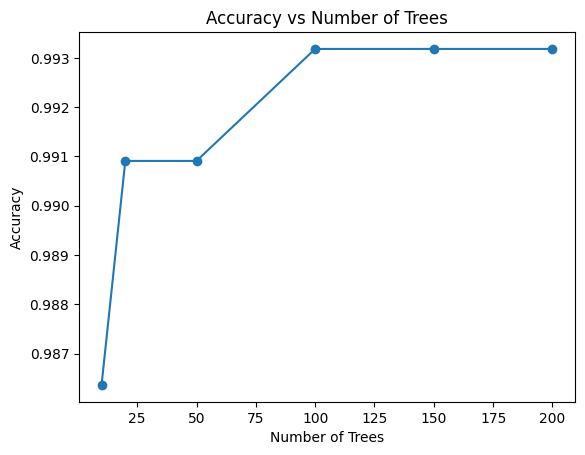

In [57]:
# Plot how model accuracy changes when we increase the number of trees
plt.plot(tree_range, accuracy_scores, marker='o')

# Add a title to explain what the graph shows
plt.title("Accuracy vs Number of Trees")

# Label the x-axis (number of trees used in the Random Forest model)
plt.xlabel("Number of Trees")

# Label the y-axis (model accuracy score)
plt.ylabel("Accuracy")

# Display the graph
plt.show()

Increasing the number of trees improves prediction stability because Random Forest combines
multiple decision trees. However, after a certain number of trees the accuracy improvement
becomes smaller.

In [36]:
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

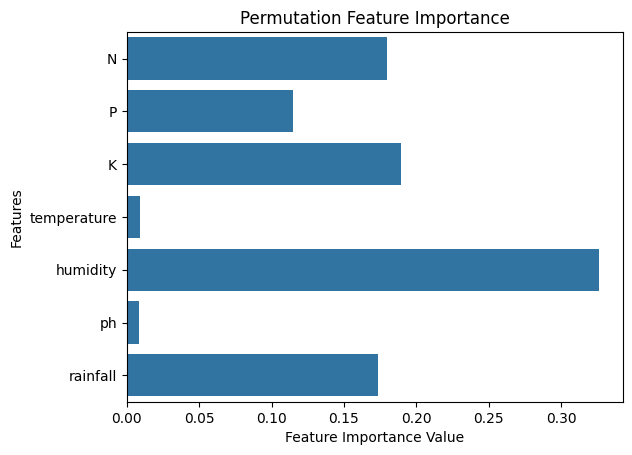

In [58]:
# Get the average importance score for each feature using permutation importance
perm_scores = perm_importance.importances_mean

# Create a bar chart to show which features affect the model predictions the most
sns.barplot(x=perm_scores, y=X.columns)

# Add a title and axis labels to explain the chart clearly
plt.title("Permutation Feature Importance")
plt.xlabel("Feature Importance Value")
plt.ylabel("Features")

# Display the plot
plt.show()

In [39]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9931818181818182


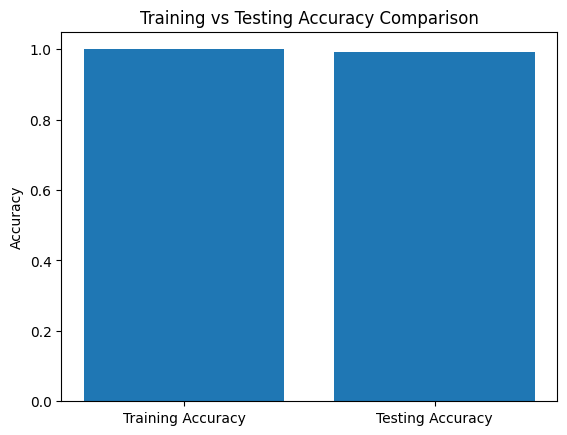

In [59]:
# Store training and testing accuracy values in a list
accuracy_values = [train_accuracy, test_accuracy]

# Create labels for the bar chart
labels = ["Training Accuracy", "Testing Accuracy"]

# Create a bar chart to compare training accuracy and testing accuracy
plt.bar(labels, accuracy_values)

# Add a title and label for better understanding of the chart
plt.title("Training vs Testing Accuracy Comparison")
plt.ylabel("Accuracy")

# Show the chart
plt.show()

## Conclusion

The Random Forest model performed well for crop recommendation because it can handle multiple
soil and climate features together. Feature importance results helped identify which
environmental factors influence crop prediction the most. Comparing training and testing
accuracy confirmed that the model generalises well.